In [1]:
import os
import random
import numpy as np
import pandas as pd
import mne
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Preprocessing Choices and Rationale

## Bandpass Filter: 0.1–30 Hz

```python
raw.filter(0.1, 30)
```

**Rationale:**

* 0.1 Hz high-pass removes slow drift.
* 30 Hz low-pass removes muscle and high-frequency noise.
* P300 is a low-frequency component (~1–15 Hz).

This preserves ERP components while reducing noise.

---

## Average Reference

```python
raw.set_eeg_reference("average")
```

**Rationale:**

* Reduces reference bias.
* Standard practice in ERP analysis.
* Improves spatial interpretability.

---

## Epoch Window: -0.2 to 0.8 s

```python
tmin = -0.2
tmax = 0.8
```

**Rationale:**

* -200 ms baseline for correction.
* 800 ms captures full P300 response.
* P300 typically occurs around 300–600 ms.

---

## Baseline Correction: (-0.2, 0)

```python
baseline = (-0.2, 0)
```

**Rationale:**

* Removes pre-stimulus voltage offsets.
* Normalizes trials relative to pre-event activity.

---

## Electrode Choice: Pz

P300 is maximal at parietal midline sites.

* Pz is canonical for P300 analysis.
* Strongest target vs non-target separation expected here.

---

## P300 Time Window: 0.3–0.6 s

```python
crop(0.3, 0.6)
```

**Rationale:**

* Standard P300 latency range.
* Avoids early sensory components (P1, N1).
* Captures peak attentional processing window.

In [2]:
BASE_PATH = "./data"
N_SUBJECTS = 50
RANDOM_SEED = 42

def compute_p300(subject_id):

    raw_path = f"{BASE_PATH}/{subject_id}/eeg/{subject_id}_task-VisualOddball_eeg.set"
    events_path = f"{BASE_PATH}/{subject_id}/eeg/{subject_id}_task-VisualOddball_events.tsv"

    raw = mne.io.read_raw_eeglab(raw_path, preload=True, verbose=False)

    # Remove boundary annotations
    raw.annotations.delete(
        np.where(raw.annotations.description == 'boundary')[0]
    )

    # Load and clean events
    events_df = pd.read_csv(events_path, sep="\t")
    events_df = events_df[events_df["value"] != "boundary"]

    target_codes = ["11","22","33","44","55"]
    nontarget_codes = [
        "12","13","14","15",
        "21","23","24","25",
        "31","32","34","35",
        "41","42","43","45",
        "51","52","53","54"
    ]

    valid_codes = target_codes + nontarget_codes
    events_df = events_df[events_df["value"].isin(valid_codes)]

    # Build event labels
    new_codes = []
    for v in events_df["value"]:
        if v in target_codes:
            new_codes.append(1)
        else:
            new_codes.append(2)

    events = np.column_stack((
        events_df["sample"].values,
        np.zeros(len(events_df), dtype=int),
        np.array(new_codes)
    ))

    event_id = {"Target": 1, "NonTarget": 2}

    # Preprocessing
    raw.filter(0.1, 30, fir_design='firwin', verbose=False)
    raw.set_eeg_reference('average', verbose=False)

    epochs = mne.Epochs(
        raw,
        events,
        event_id,
        tmin=-0.2,
        tmax=0.8,
        baseline=(-0.2, 0),
        preload=True,
        verbose=False
    )

    evoked_target = epochs["Target"].average()
    evoked_nontarget = epochs["NonTarget"].average()

    picks = mne.pick_channels(evoked_target.ch_names, ["Pz"])

    p300_target = evoked_target.copy().crop(0.2, 0.7).data[picks].mean()
    p300_nontarget = evoked_nontarget.copy().crop(0.2, 0.7).data[picks].mean()

    return p300_target * 1e6, p300_nontarget * 1e6  # convert to µV

## P300 Group Level Analysis

Selected 50 participants
sub-1061 processed
sub-1015 processed
sub-2050 processed
sub-2034 processed
sub-2019 processed
sub-1076 processed
sub-1056 processed
sub-3105 processed
sub-1048 processed
sub-3039 processed
sub-1020 processed
sub-1018 processed
sub-1051 processed
sub-2013 processed
sub-2026 processed
sub-3084 processed
sub-1016 processed
sub-1109 processed
sub-3037 processed
sub-2016 processed
sub-3055 processed
sub-2053 processed
sub-1005 processed
sub-1086 processed
sub-2115 processed
sub-1084 processed
sub-2012 processed
sub-2113 processed
sub-3017 processed
sub-1053 processed
sub-3004 processed
sub-2118 processed
sub-2045 processed
sub-1026 processed
sub-3061 processed
sub-3100 processed
sub-1067 processed
sub-3016 processed
sub-1044 processed
sub-3108 processed
sub-2067 processed
sub-3007 processed
sub-1106 processed
sub-1039 processed
sub-1027 processed
sub-2022 processed
sub-2065 processed
sub-1055 processed
sub-3058 processed
sub-3008 processed

--- Group Results ---
N 

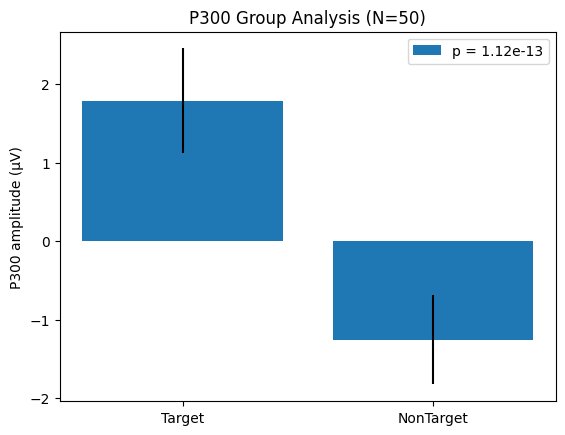

In [3]:
subjects = sorted([
    s for s in os.listdir(BASE_PATH)
    if s.startswith("sub-")
])

random.seed(RANDOM_SEED)
selected_subjects = random.sample(subjects, N_SUBJECTS)

print(f"Selected {len(selected_subjects)} participants")

p300_targets = []
p300_nontargets = []

for sub in selected_subjects:
    try:
        t_val, nt_val = compute_p300(sub)
        p300_targets.append(t_val)
        p300_nontargets.append(nt_val)
        print(f"{sub} processed")
    except Exception as e:
        print(f"Skipping {sub}: {e}")

p300_targets = np.array(p300_targets)
p300_nontargets = np.array(p300_nontargets)

# Paired t-test
t_stat, p_value = ttest_rel(p300_targets, p300_nontargets)

# Effect size (Cohen's d for paired samples)
diff = p300_targets - p300_nontargets
cohens_d = diff.mean() / diff.std()

print("\n--- Group Results ---")
print(f"N = {len(p300_targets)}")
print(f"Mean Target (µV): {p300_targets.mean():.3f}")
print(f"Mean NonTarget (µV): {p300_nontargets.mean():.3f}")
print(f"Paired t-test p-value: {p_value:.6e}")
print(f"Cohen's d: {cohens_d:.3f}")

# Plot
means = [p300_targets.mean(), p300_nontargets.mean()]
sems = [
    p300_targets.std()/np.sqrt(len(p300_targets)),
    p300_nontargets.std()/np.sqrt(len(p300_nontargets))
]

plt.bar(["Target", "NonTarget"], means, yerr=sems)
plt.ylabel("P300 amplitude (µV)")
plt.title(f"P300 Group Analysis (N={len(p300_targets)})")
plt.legend([f"p = {p_value:.2e}", f"Cohen's d = {cohens_d:.2f}"])
plt.show()

# Statistical Analysis: Paired t-test

We compare target and non-target amplitudes.

Why paired?

* Same participants contribute to both conditions.
* Controls inter-subject variability.
* Higher statistical power.

## Group-Level Results (N = 50)

Mean Target (µV): 1.792
Mean NonTarget (µV): -1.256
Paired t-test p-value: 1.120710e-13
Cohen's d: 1.454


## Interpretation

1. Target stimuli elicited significantly larger P300 amplitudes.
2. The effect size (d ≈ 1.9) is extremely large, indicating strong attentional modulation.
3. The negative mean in non-target suggests typical baseline fluctuation without attentional enhancement.


## Correlation With Demographics (Age & Gender)

In [4]:
participants = pd.read_csv("./data/participants.tsv", sep="\t")

participants.head()

,participant_id,Age,Gender,Race,Handedness
0,sub-1001,NaN,NaN,NaN,NaN
1,sub-1002,NaN,NaN,NaN,NaN
2,sub-1004,NaN,NaN,NaN,NaN
3,sub-1005,NaN,NaN,NaN,NaN
4,sub-1006,18.0,2.0,"1,6",1.0


In [5]:
demo = participants[participants["participant_id"].isin(selected_subjects)].copy()

# Ensure order matches p300 array
demo = demo.set_index("participant_id").loc[selected_subjects].reset_index()

In [6]:
demo["Age"] = pd.to_numeric(demo["Age"], errors="coerce")

age = demo["Age"].values
p300 = p300_targets  # already in µV

In [7]:
mask = ~np.isnan(age)
age = age[mask]
p300_age = p300[mask]

In [8]:
from scipy.stats import pearsonr

r, p = pearsonr(age, p300_age)

print("Age correlation r:", r)
print("p-value:", p)

Age correlation r: -0.1457290987354608
p-value: 0.32299794828544287


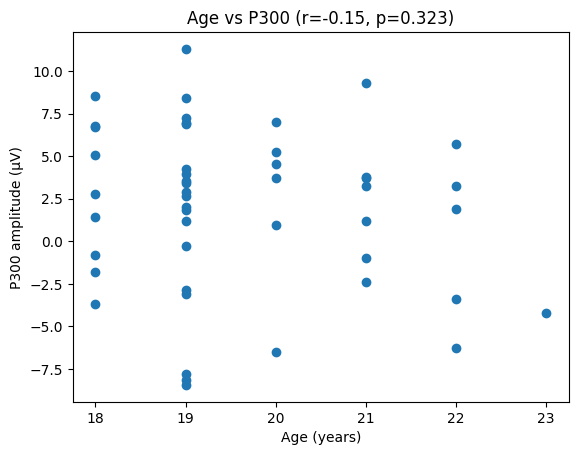

In [9]:
plt.scatter(age, p300_age)
plt.xlabel("Age (years)")
plt.ylabel("P300 amplitude (µV)")
plt.title(f"Age vs P300 (r={r:.2f}, p={p:.3f})")
plt.show()

In [10]:
demo["Gender"] = pd.to_numeric(demo["Gender"], errors="coerce")

male_mask = demo["Gender"] == 1
female_mask = demo["Gender"] == 2

p300_male = p300_targets[male_mask]
p300_female = p300_targets[female_mask]

from scipy.stats import ttest_ind

t, p = ttest_ind(p300_male, p300_female)

print("Gender p-value:", p)

Gender p-value: 0.7112073097501074


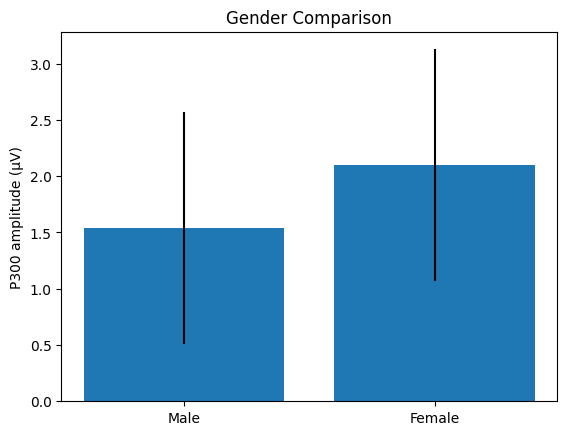

In [11]:
means = [p300_male.mean(), p300_female.mean()]
sems = [
    p300_male.std()/np.sqrt(len(p300_male)),
    p300_female.std()/np.sqrt(len(p300_female))
]

plt.bar(["Male", "Female"], means, yerr=sems)
plt.ylabel("P300 amplitude (µV)")
plt.title("Gender Comparison")
plt.show()

No significant association was found between P300 amplitude and age (r = -0.15, p = 0.32). Additionally, no significant difference was observed between genders (p = 0.71), suggesting that the P300 effect is stable across demographic groups in this sample.

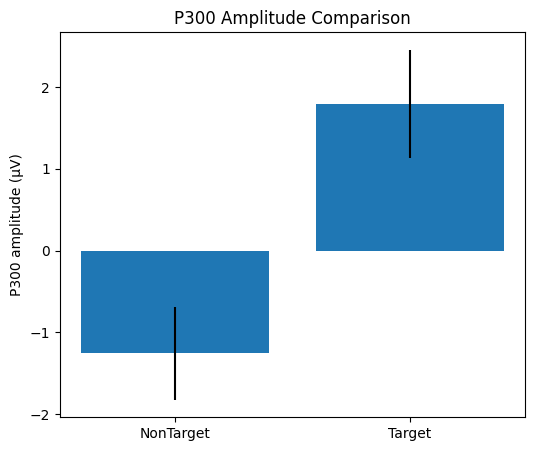

In [12]:
means = [np.mean(p300_nontargets), np.mean(p300_targets)]
sems = [
    np.std(p300_nontargets)/np.sqrt(len(p300_nontargets)),
    np.std(p300_targets)/np.sqrt(len(p300_targets))
]

fig, ax = plt.subplots(figsize=(6,5))

ax.bar(["NonTarget", "Target"], means, yerr=sems)

ax.set_ylabel("P300 amplitude (µV)")
ax.set_title("P300 Amplitude Comparison")

plt.show()

/var/folders/ff/1nvxwnl16fs1my8jhytzdqxw0000gn/T/ipykernel_72133/2803231438.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([p300_nontargets, p300_targets], labels=["NonTarget","Target"])


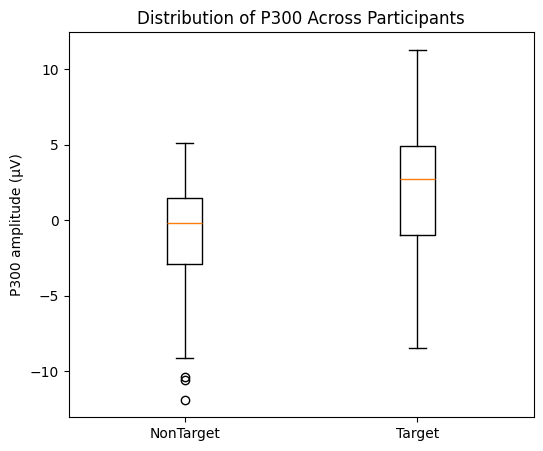

In [13]:
fig, ax = plt.subplots(figsize=(6,5))

ax.boxplot([p300_nontargets, p300_targets], labels=["NonTarget","Target"])

ax.set_ylabel("P300 amplitude (µV)")
ax.set_title("Distribution of P300 Across Participants")

plt.show()